In [ ]:
!pip install kagglehub[pandas-datasets]

# Get Datasets

In [ ]:
# Install dependencies as needed:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
movie_path = "movie.csv"
rating_path = "rating.csv"

# Load the latest version
movie_df = kagglehub.load_dataset( # Loads the movie.csv section of MovieLens. This has genre information for each movie.
  KaggleDatasetAdapter.PANDAS,
  "grouplens/movielens-20m-dataset",
  movie_path,
)
rating_df = kagglehub.load_dataset( # Loads the rating.csv section of MovieLens. This has rating data for each movie.
    KaggleDatasetAdapter.PANDAS,
    "grouplens/movielens-20m-dataset",
    rating_path,
)


/tmp/ipykernel_18552/3387300997.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  movie_df = kagglehub.load_dataset( # Loads the movie.csv section of MovieLens. This has genre information for each movie.


Using Colab cache for faster access to the 'movielens-20m-dataset' dataset.


/tmp/ipykernel_18552/3387300997.py:15: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  rating_df = kagglehub.load_dataset( # Loads the rating.csv section of MovieLens. This has rating data for each movie.


Using Colab cache for faster access to the 'movielens-20m-dataset' dataset.


# Merge Datasets

In [ ]:
avg_ratings = rating_df.groupby("movieId")["rating"].mean().reset_index() #get average rating per movieid
count_ratings = rating_df.groupby("movieId")["rating"].count().reset_index() #get average rating per movieid
df = movie_df.merge(avg_ratings, on="movieId") #merge the movies dataframe with the average_ratings dataframe
df = df.merge(count_ratings, on="movieId") #merge the movies dataframe with the rating counts dataframe
df.rename(columns={"rating_x": "rating", "rating_y": "count"}, inplace=True)
df.head()

,movieId,title,genres,rating,count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.921240,49695
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.211977,22243
2,3,Grumpier Old Men (1995),Comedy|Romance,3.151040,12735
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.861393,2756
4,5,Father of the Bride Part II (1995),Comedy,3.064592,12161


# Seperate Year from Title

In [ ]:
year_list = []
df["year"] = df["title"].str.extract(r"\((\d{4})\)").astype(float)
df["title"] = df["title"].str.replace(r"\s*\(\d{4}\)", "", regex=True)
df

,movieId,title,genres,rating,count,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,3.921240,49695,1995.0
1,2,Jumanji,Adventure|Children|Fantasy,3.211977,22243,1995.0
2,3,Grumpier Old Men,Comedy|Romance,3.151040,12735,1995.0
3,4,Waiting to Exhale,Comedy|Drama|Romance,2.861393,2756,1995.0
4,5,Father of the Bride Part II,Comedy,3.064592,12161,1995.0
...,...,...,...,...,...,...
26739,131254,Kein Bund für's Leben,Comedy,4.000000,1,2007.0
26740,131256,"Feuer, Eis & Dosenbier",Comedy,4.000000,1,2002.0
26741,131258,The Pirates,Adventure,2.500000,1,2014.0
26742,131260,Rentun Ruusu,(no genres listed),3.000000,1,2001.0


# Exploratory Data Analysis

Gets the shape of the dataframe (eg. amount of rows, columns)

In [ ]:
df.shape

(26744, 6)

Gets information about the dataset regarding how many null values there are, and drop the null values

In [ ]:
import matplotlib.pyplot as plt

df.info() #Checking for null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  26744 non-null  int64  
 1   title    26744 non-null  object 
 2   genres   26744 non-null  object 
 3   rating   26744 non-null  float64
 4   count    26744 non-null  int64  
 5   year     26722 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.2+ MB


In [ ]:
df

,movieId,title,genres,rating,count,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,3.921240,49695,1995.0
1,2,Jumanji,Adventure|Children|Fantasy,3.211977,22243,1995.0
2,3,Grumpier Old Men,Comedy|Romance,3.151040,12735,1995.0
3,4,Waiting to Exhale,Comedy|Drama|Romance,2.861393,2756,1995.0
4,5,Father of the Bride Part II,Comedy,3.064592,12161,1995.0
...,...,...,...,...,...,...
26739,131254,Kein Bund für's Leben,Comedy,4.000000,1,2007.0
26740,131256,"Feuer, Eis & Dosenbier",Comedy,4.000000,1,2002.0
26741,131258,The Pirates,Adventure,2.500000,1,2014.0
26742,131260,Rentun Ruusu,(no genres listed),3.000000,1,2001.0


The genres are separated by dividers (|), which our model won't be able to understand as is.

In [ ]:
df["genres"] = df["genres"].apply(lambda x: x.split("|")) # Splits the genres by the | divider and makes it and a list
df["genres"]

,genres
0,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,"[Adventure, Children, Fantasy]"
2,"[Comedy, Romance]"
3,"[Comedy, Drama, Romance]"
4,[Comedy]
...,...
26739,[Comedy]
26740,[Comedy]
26741,[Adventure]
26742,[(no genres listed)]


# Genre distribution

In [ ]:
category_dict = {} #create a dictionary that stores the number of movies in the dataset with a given genre
for row in range(len(df["genres"])): # checks each row for the genres and modifies the category dictionary accordingly.
  row_list = df["genres"][row]
  for genre in range(len(row_list)):
    if(row_list[genre].lower() not in category_dict):
      category_dict[row_list[genre].lower()] = 1
    category_dict[row_list[genre].lower()]+=1
category_dict

{'adventure': 2288,
 'animation': 1016,
 'children': 1119,
 'comedy': 8233,
 'fantasy': 1399,
 'romance': 4030,
 'drama': 13063,
 'action': 3467,
 'crime': 2890,
 'thriller': 4130,
 'horror': 2591,
 'mystery': 1490,
 'sci-fi': 1721,
 'imax': 196,
 'documentary': 2392,
 'war': 1174,
 'musical': 1017,
 'western': 657,
 'film-noir': 323,
 '(no genres listed)': 243}

This graph shows that drama is the most popular genre for movies within the dataset, meaning that the results will be biased towards drama films.

([<matplotlib.axis.XTick at 0x79fbcc347bf0>,
 [Text(0, 0, 'drama'),
  Text(1, 0, 'comedy'),
  Text(2, 0, 'thriller'),
  Text(3, 0, 'romance'),
  Text(4, 0, 'action'),
  Text(5, 0, 'crime'),
  Text(6, 0, 'horror'),
  Text(7, 0, 'documentary'),
  Text(8, 0, 'adventure'),
  Text(9, 0, 'sci-fi'),
  Text(10, 0, 'mystery'),
  Text(11, 0, 'fantasy'),
  Text(12, 0, 'war'),
  Text(13, 0, 'children'),
  Text(14, 0, 'musical'),
  Text(15, 0, 'animation'),
  Text(16, 0, 'western'),
  Text(17, 0, 'film-noir'),
  Text(18, 0, '(no genres listed)'),
  Text(19, 0, 'imax')])

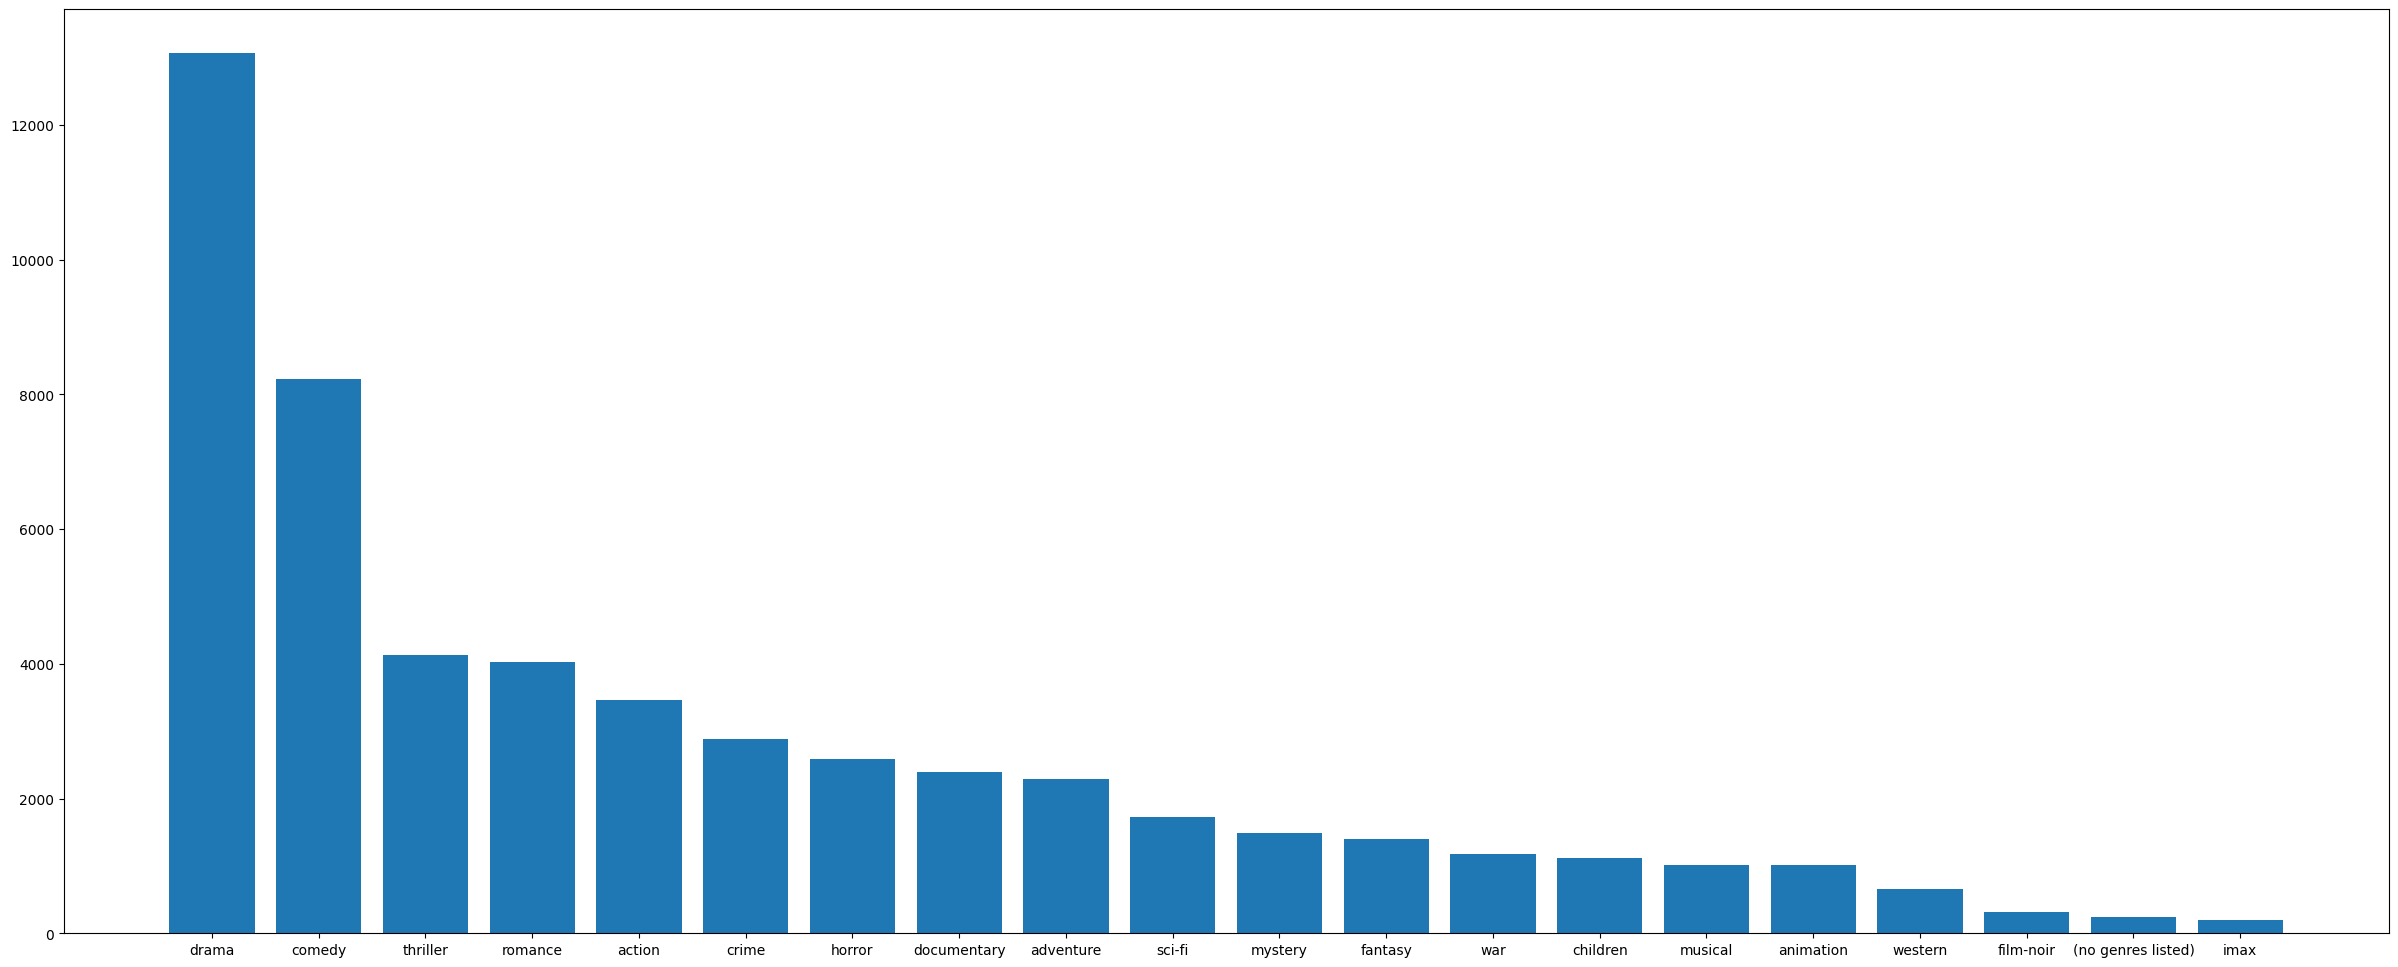

In [ ]:
 #Create a bar graph using the dictionary
category_dict = dict(sorted(category_dict.items(), key=lambda item: item[1], reverse=True)) # Sorts the dictionary by value, descending ()
plt.figure(figsize=(30, 12))
plt.bar(range(len(category_dict)), list(category_dict.values()), align='center')
plt.xticks(range(len(category_dict)), list(category_dict.keys()))

# Rating Distribution

In [ ]:
rating_dict = rating_df["rating"].value_counts()# Use these methods since they are optimized in C to take less time than a Python loop.
rating_dict = rating_dict.sort_index()
rating_dict

,count
rating,
0.5,239125
1.0,680732
1.5,279252
2.0,1430997
2.5,883398
3.0,4291193
3.5,2200156
4.0,5561926
4.5,1534824


This graph shows that ratings tend to be in the 3-5 range, with negative reviews being less common.

([<matplotlib.axis.XTick at 0x79fc03194560>,
 [Text(0, 0, '4.0'),
  Text(1, 0, '3.0'),
  Text(2, 0, '5.0'),
  Text(3, 0, '3.5'),
  Text(4, 0, '4.5'),
  Text(5, 0, '2.0'),
  Text(6, 0, '2.5'),
  Text(7, 0, '1.0'),
  Text(8, 0, '1.5'),
  Text(9, 0, '0.5')])

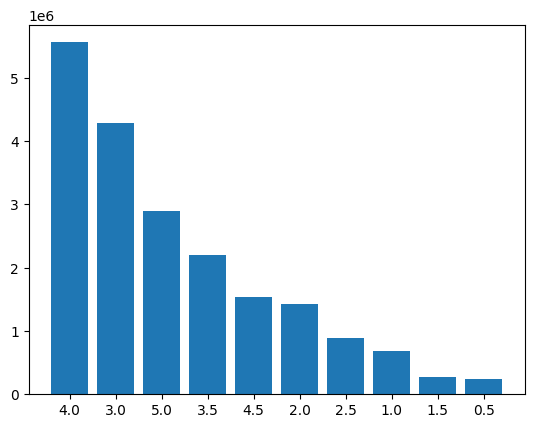

In [ ]:
rating_dict = dict(sorted(rating_dict.items(), key=lambda item: item[1], reverse=True))
plt.bar(range(len(rating_dict)), list(rating_dict.values()), align='center')
plt.xticks(range(len(rating_dict)), list(rating_dict.keys()))
#rating_dict.plot.bar()

# Content Based Filtering

## Cosine Similarity

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def movie_recommender_cosine(title, year, df): #this function takes in a movie title and a movie dataframe and recommends a movie based on genre
  mlb = MultiLabelBinarizer(sparse_output=True)

  X = mlb.fit_transform(list(df["genres"]))
  new_movie = list(df[df["title"] == title]["genres"]) #gets the genres associated with the movie title given

  new_movie_vec = mlb.transform(new_movie)
  sims = cosine_similarity(new_movie_vec, X).flatten()

  # top 10 most similar movies
  top_indices = np.argsort(sims)[::-1][:10]
  recommendations = df.iloc[top_indices]
  recommendations = recommendations.sort_values(by="rating", ascending=False) #sorts recommendations by rating
  recommendations = recommendations.reset_index(drop=True)
  recommendations = recommendations[recommendations["title"]!=title] #gets all of the recommendations that don't include the current movie
  recommendations = recommendations[abs(recommendations["year"]-year)<=10] #restricts recommendations to those within ten years of the current movie
  #print(recommendations)
  return list(recommendations.iloc[:10]["title"]) #gets the top recommendation

In [ ]:
movie_recommender_cosine("Toy Story", 1995, df)

['Monsters, Inc.',
 'Toy Story 2',
 "Emperor's New Groove, The",
 'DuckTales: The Movie - Treasure of the Lost Lamp',
 'Antz',
 'Adventures of Rocky and Bullwinkle, The']

# Try it yourself!
Input your favorite movie into the function to see similar ones.

In [ ]:
movie_recommender_cosine("Your Movie Here", "Release Date Here", df)